
# Free Throw Success Classification (Beginner-Friendly)

This project uses the `combined.csv` dataset (NBA per-game player-season stats from Basketball-Reference) to build **a classification model**.

## Important: What is the target here?
This dataset is **not shot-by-shot free throw attempts** (it does not have a `made/missed` outcome per free throw). Instead it has season-level *rates* like `FT%`.

So we define a clean binary target:

- `target = 1` if a player's **season FT%** is **greater than or equal to the league average FT%** for that same season.
- `target = 0` otherwise.

This gives us a meaningful and well-defined classification task: **is this player an above-average free throw shooter (for that season)?**

We also take care to avoid leakage:
- We **drop `FT%` from the features** (because it's used to build the target).
- We avoid directly using anything that is a trivial re-expression of `FT%`.


# Model Notebook

This notebook:
- loads the saved train/test split and preprocessing pipeline from `artifacts/data_split_and_preprocess.joblib`
- trains a model inside a scikit-learn `Pipeline` (preprocess + estimator)
- evaluates using Accuracy, Confusion Matrix, Precision/Recall/F1
- saves a small metrics JSON to `artifacts/metrics_<model>.json` for the comparison notebook


In [1]:
import joblib
from pathlib import Path

ARTIFACT_DIR = Path('artifacts')
data = joblib.load(ARTIFACT_DIR / 'data_split_and_preprocess.joblib')

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
preprocess = data['preprocess']

print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (16468, 28) Test: (4117, 28)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

def evaluate_classifier(model, X_test, y_test, model_name: str):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    print(f'== {model_name} ==')
    print('Accuracy:', acc)
    print('\nClassification report:')
    print(classification_report(y_test, y_pred, digits=3))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Show a few prediction errors
    err_idx = np.where(y_pred != np.array(y_test))[0]
    print('Num errors:', len(err_idx))
    if len(err_idx) > 0:
        sample = err_idx[:10]
        out = pd.DataFrame({'y_true': np.array(y_test)[sample], 'y_pred': y_pred[sample]})
        display(out)

    # Return metrics for comparison notebook
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    return {
        'model': model_name,
        'accuracy': float(acc),
        'f1_weighted': float(report['weighted avg']['f1-score']),
        'f1_macro': float(report['macro avg']['f1-score']),
        'precision_weighted': float(report['weighted avg']['precision']),
        'recall_weighted': float(report['weighted avg']['recall']),
    }


## Train: Neural Network (MLP)

== ANN (sklearn MLP) ==
Accuracy: 0.8916686907942677

Classification report:
              precision    recall  f1-score   support

           0      0.881     0.916     0.898      2148
           1      0.904     0.865     0.884      1969

    accuracy                          0.892      4117
   macro avg      0.893     0.891     0.891      4117
weighted avg      0.892     0.892     0.892      4117



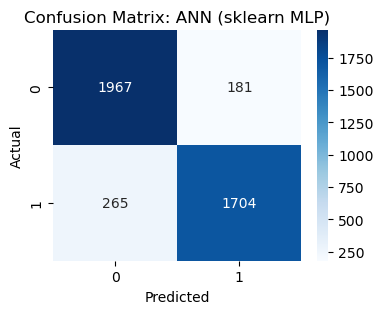

Num errors: 446


,y_true,y_pred
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0
5,1,0
6,1,0
7,0,1
8,1,0
9,1,0


{'model': 'ANN (sklearn MLP)',
 'accuracy': 0.8916686907942677,
 'f1_weighted': 0.8915269146355372,
 'f1_macro': 0.8912247963925282,
 'precision_weighted': 0.8921319737153756,
 'recall_weighted': 0.8916686907942677}

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier

# Using sklearn MLPClassifier because TensorFlow/PyTorch are not installed in this environment.
clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        alpha=1e-4,
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=42,
        early_stopping=True
    )),
])

clf.fit(X_train, y_train)
metrics = evaluate_classifier(clf, X_test, y_test, 'ANN (sklearn MLP)')
metrics


## Save Metrics

In [4]:
import json

metrics_path = ARTIFACT_DIR / 'metrics_08_ANN_MLP_FreeThrow.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved', metrics_path)


Saved artifacts/metrics_08_ANN_MLP_FreeThrow.json
